### Metriksiz Test

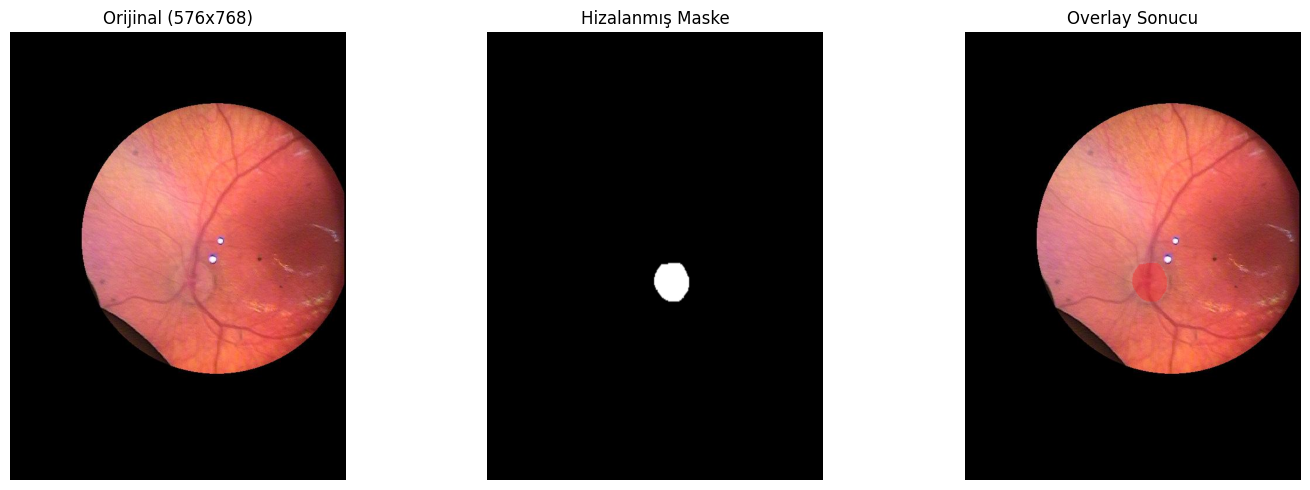

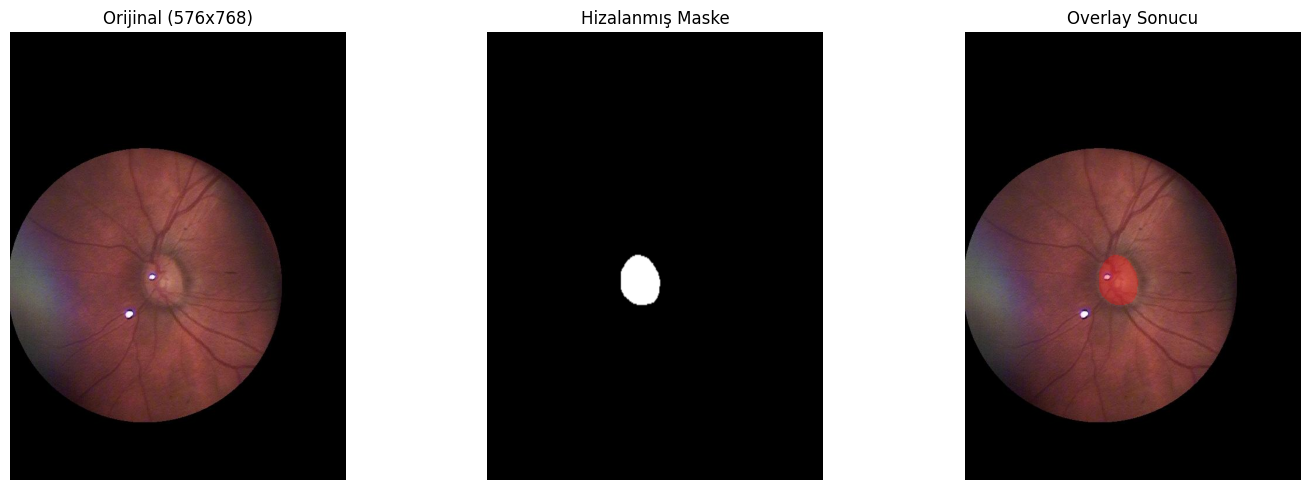

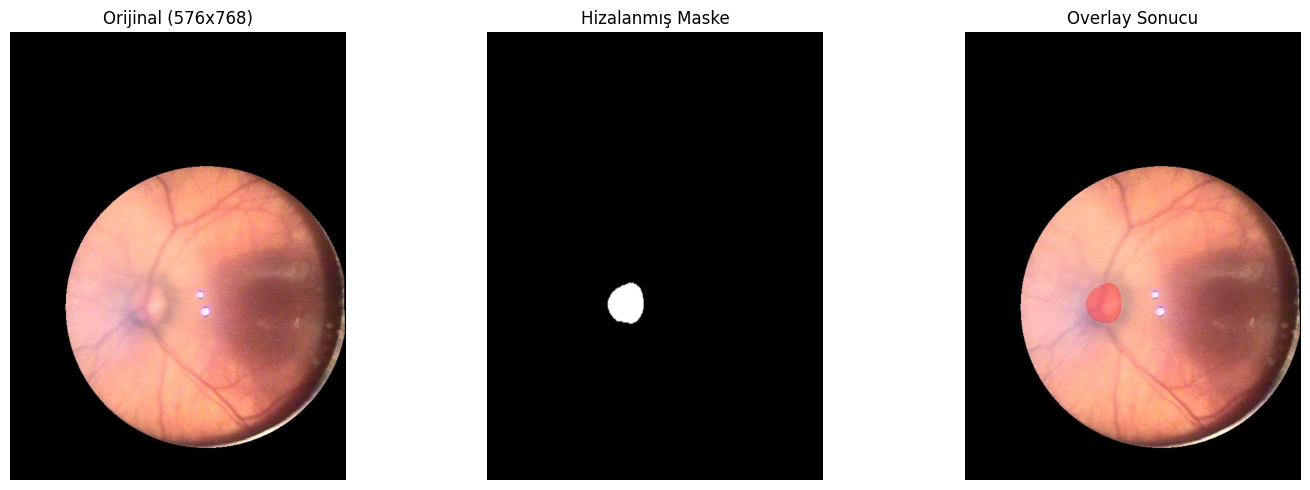

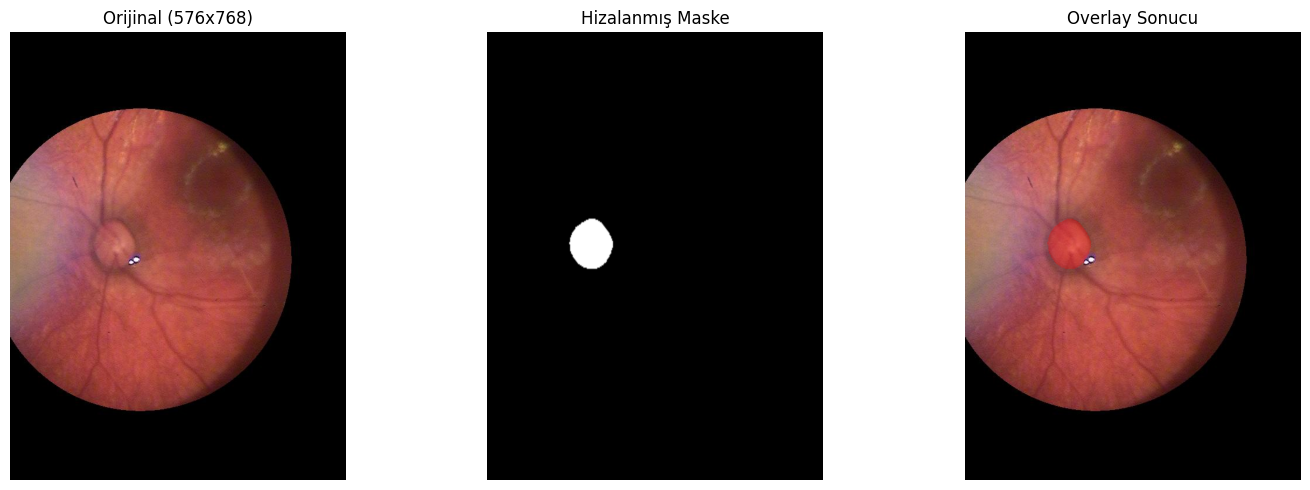

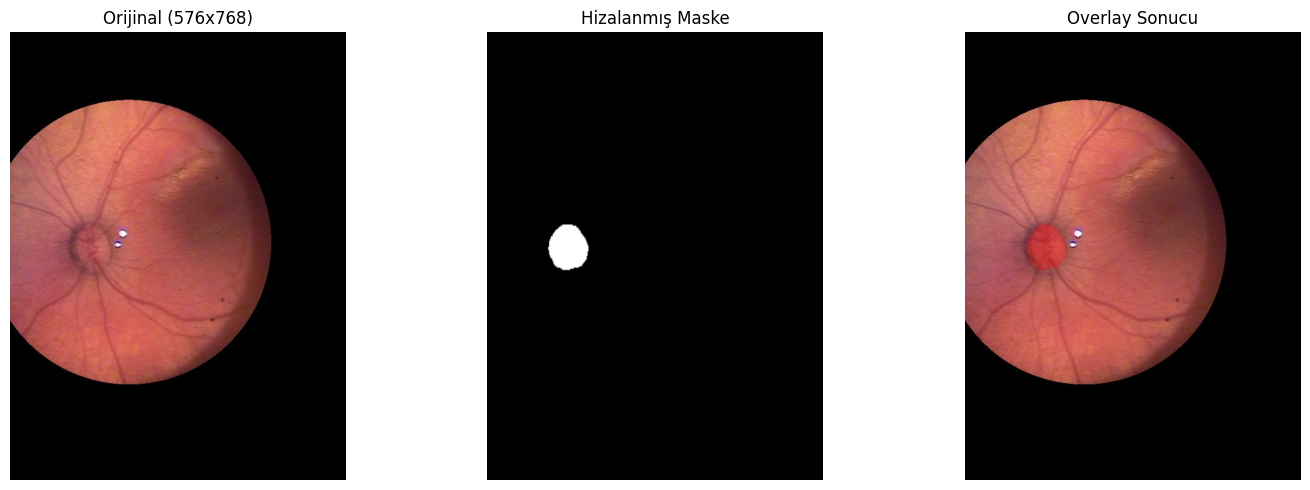

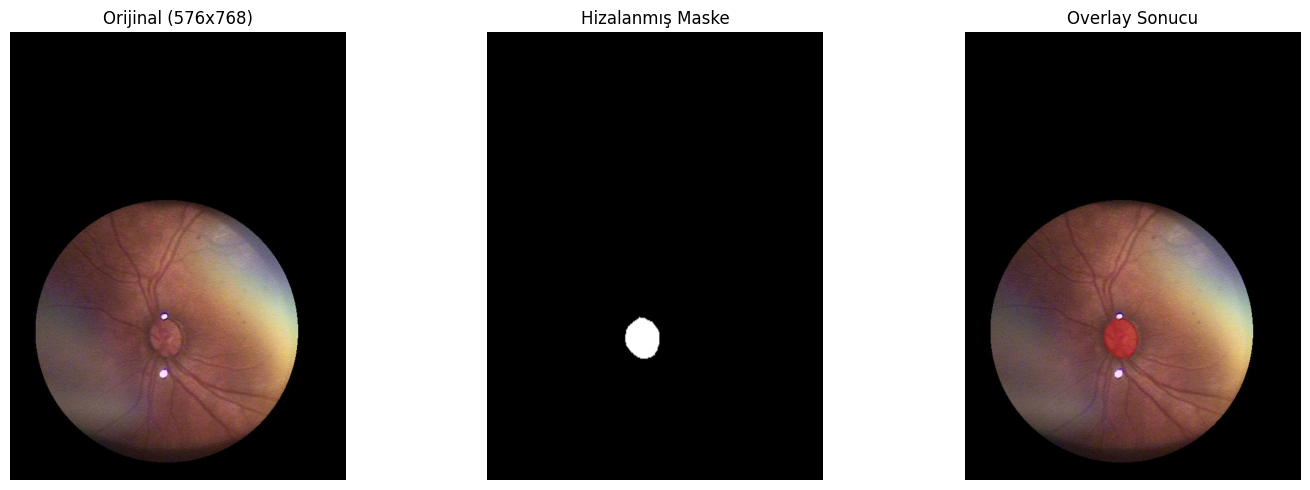

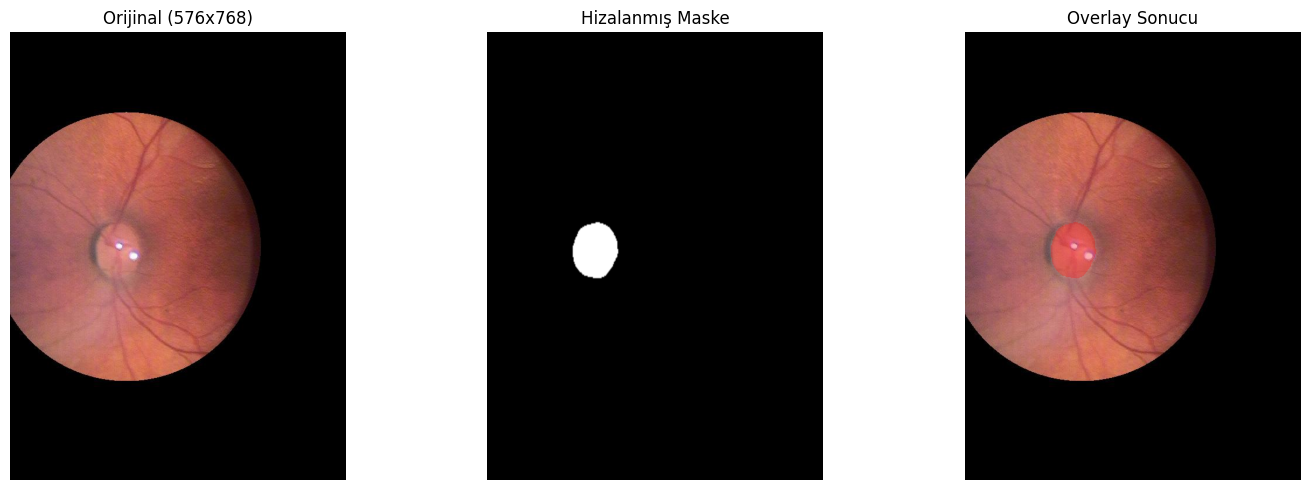

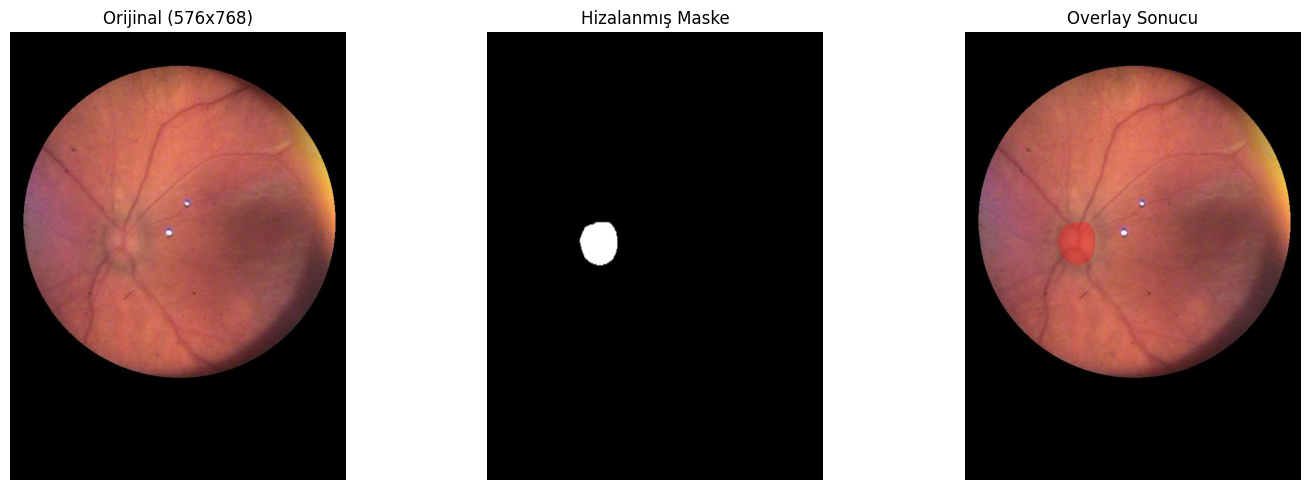

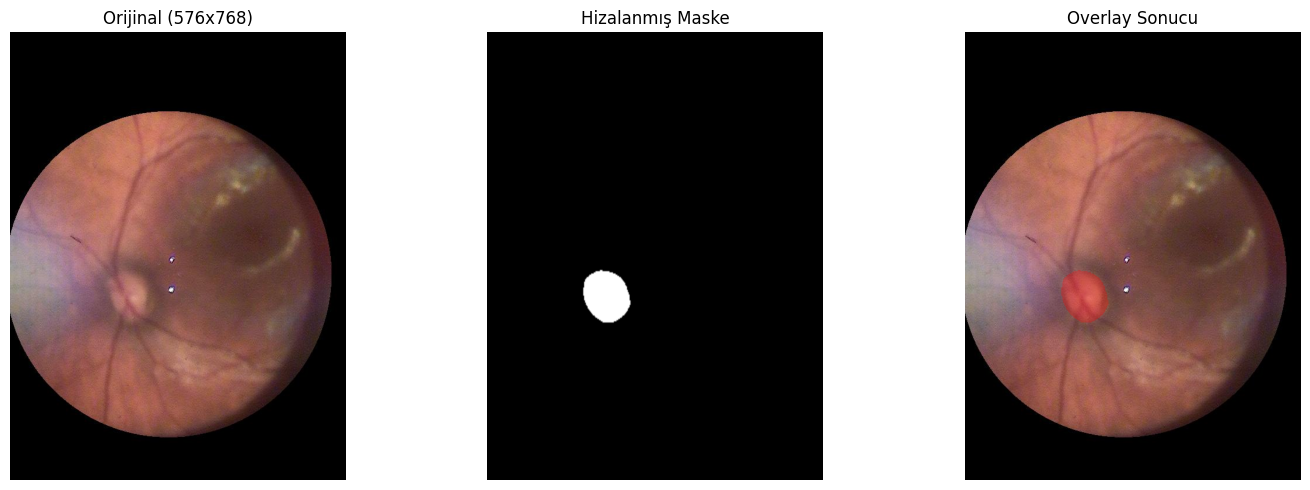

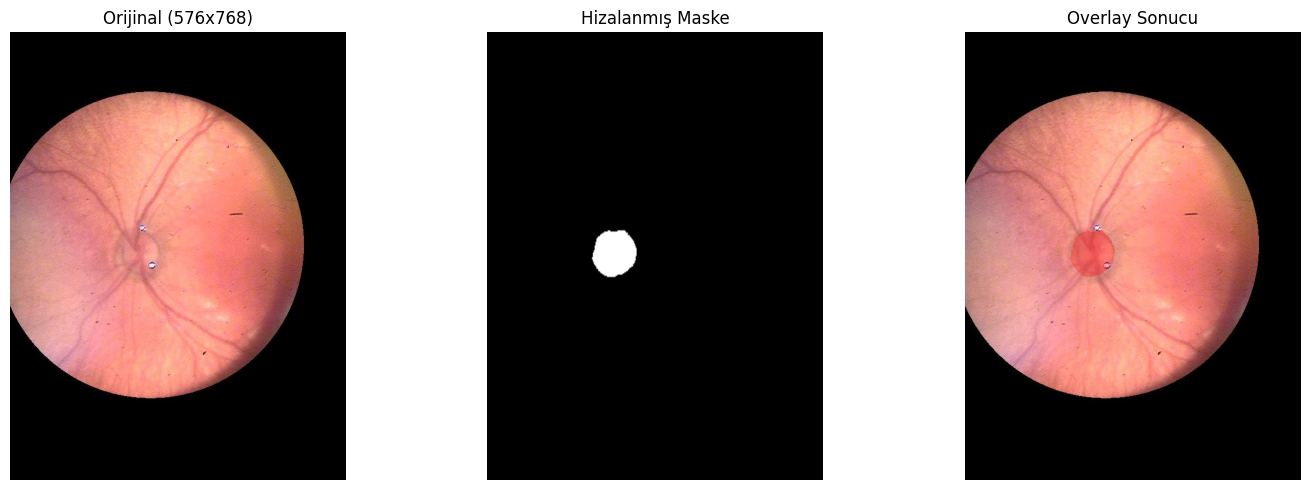

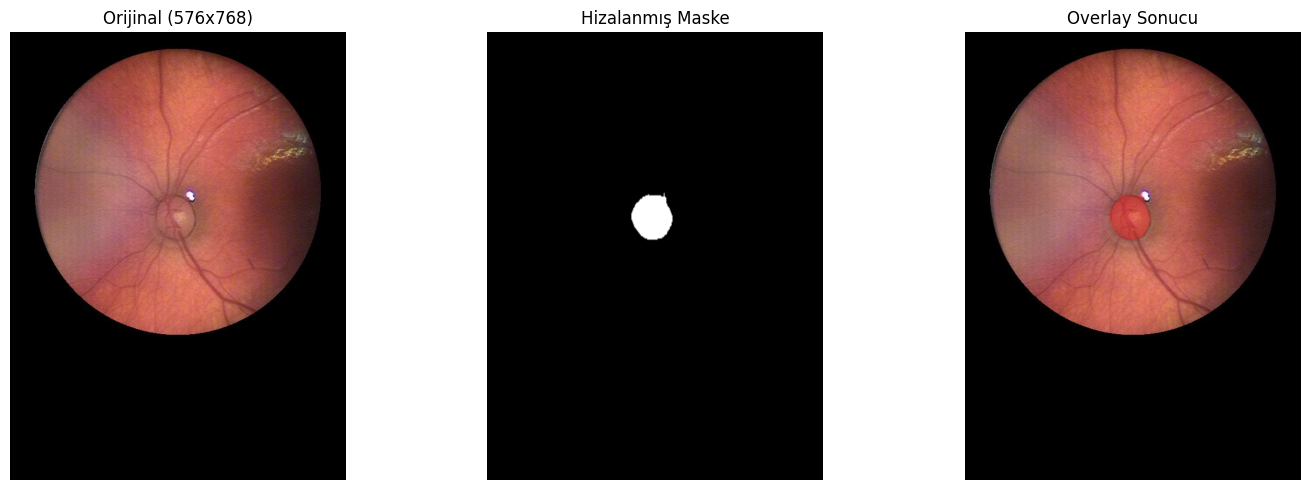

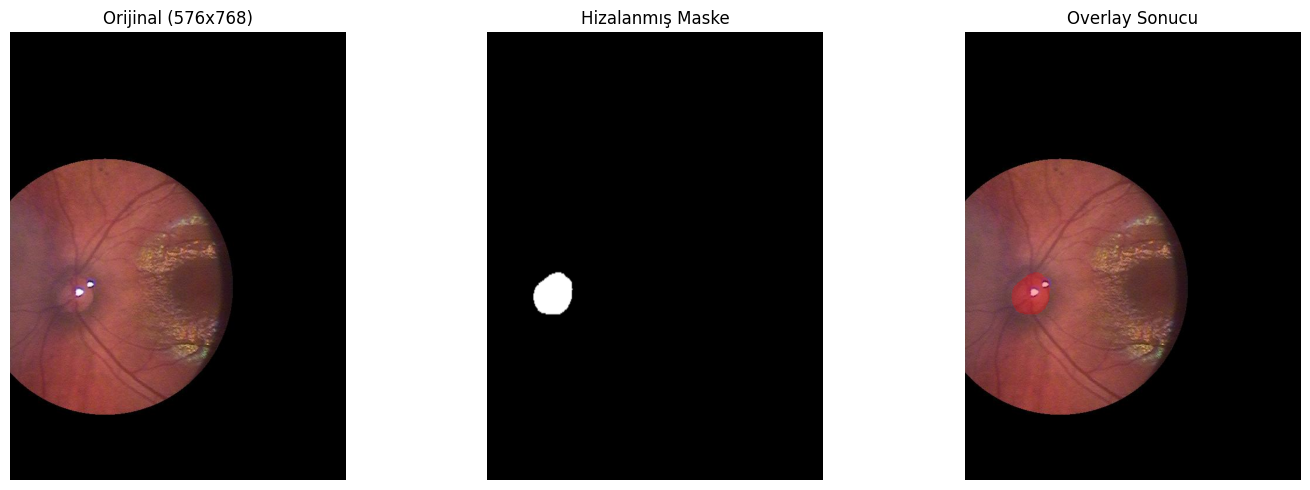

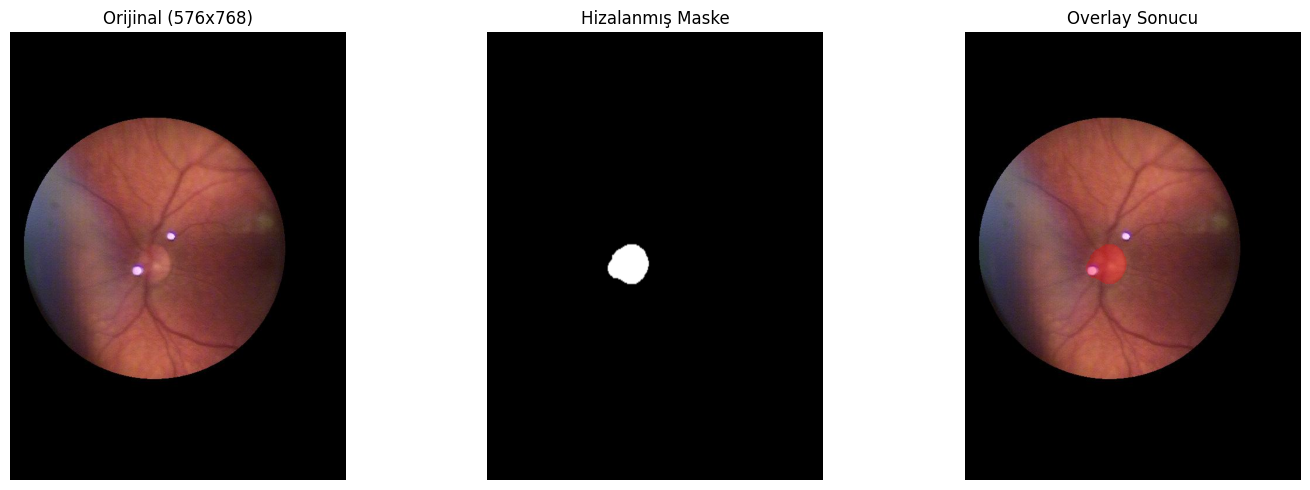

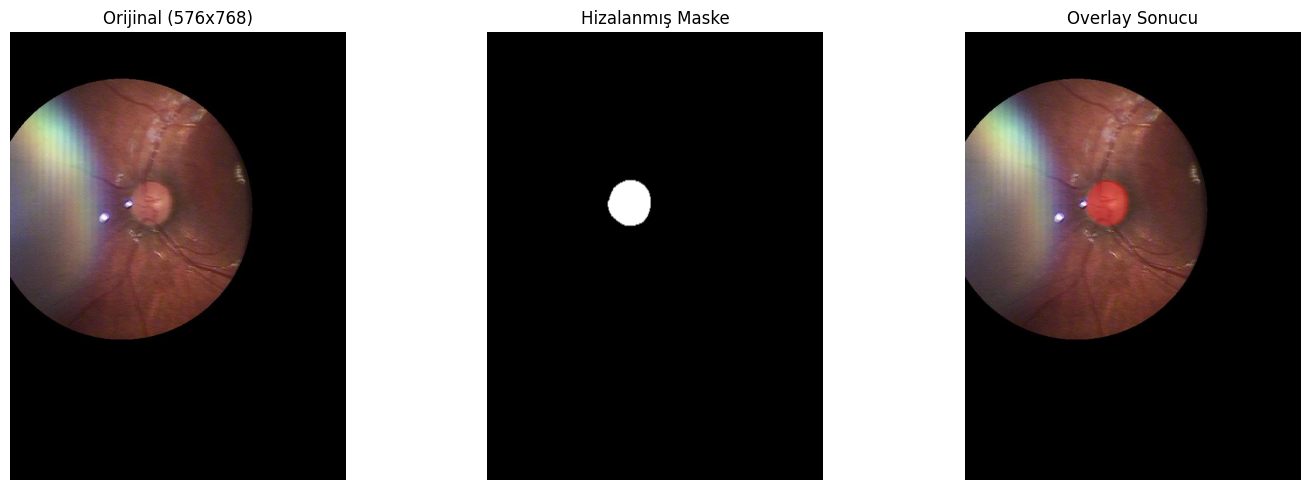

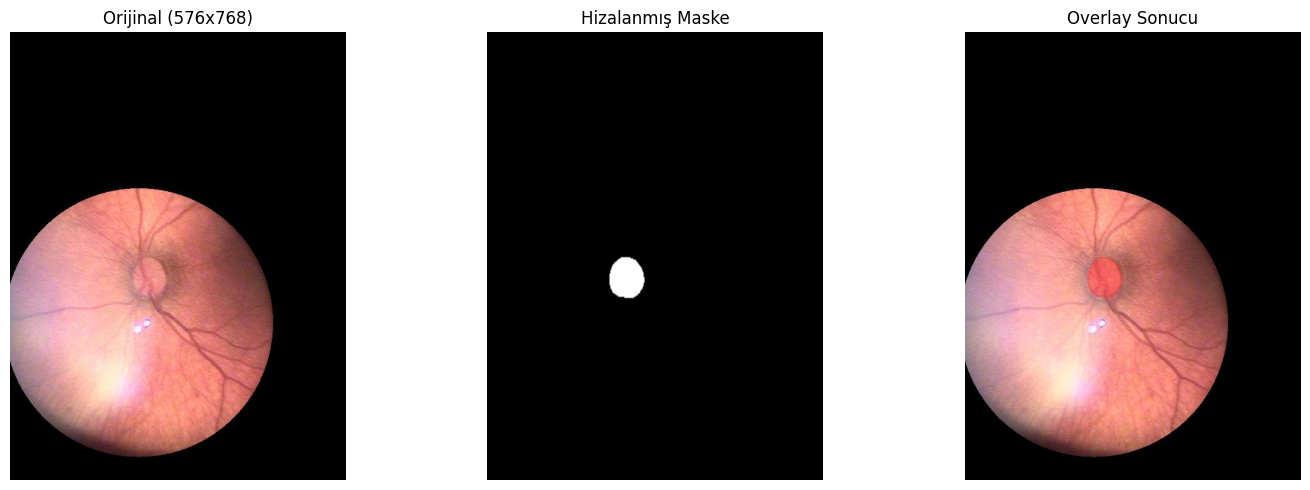

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from od_mimari import get_segmentation_model
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 1. AYARLAR VE CİHAZ
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "od_bebek_model.pth"
val_img_dir = r"C:\Users\Dogan\Desktop\Ayberk Dosyalar\Bitirme Projesi\Fundus\all_fundus_datas\od_segment_bebek_data\Test_Image"
val_mask_dir = r"C:\Users\Dogan\Desktop\Ayberk Dosyalar\Bitirme Projesi\Fundus\all_fundus_datas\od_segment_bebek_data\Test_Mask"

# 2. MODELİ YÜKLE
model = get_segmentation_model().to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

# 3. TRANSFORM (Modelin eğitildiği boyut)
test_transform = A.Compose([
    A.Resize(384, 384),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# 4. GÖRÜNTÜ LİSTESİ
images_list = [f for f in os.listdir(val_img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# 5. TAHMİN DÖNGÜSÜ
for img_name in images_list:
    img_path = os.path.join(val_img_dir, img_name)
    
    # Orijinal resmi oku
    image_bgr = cv2.imread(img_path)
    if image_bgr is None: continue
    
    h_orig, w_orig = image_bgr.shape[:2]
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    
    # Modele giriş hazırlığı
    input_tensor = test_transform(image=image_rgb)["image"].unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        # Olasılık haritasını binary maskeye çevir (384x384)
        prediction = (output > 0.5).cpu().numpy().squeeze()
    
    # --- BOYUT DÜZELTME ---
    # Kare tahmini orijinal resmin en-boy oranına geri getiriyoruz
    prediction_resized = cv2.resize(prediction.astype(np.float32), (w_orig, h_orig))
    
    # --- OVERLAY (Üst Üste Bindirme) OLUŞTURMA ---
    # Tahmini kırmızı renkte bir maske olarak hazırla
    overlay = image_rgb.copy()
    mask_indices = prediction_resized > 0.5
    overlay[mask_indices] = [255, 0, 0] # Maskeli yerleri kırmızı yap
    
    # Şeffaf birleşim (Orijinal %70, Kırmızı Maske %30)
    final_output = cv2.addWeighted(image_rgb, 0.7, overlay, 0.3, 0)
    
    # 6. GÖRSELLEŞTİRME
    plt.figure(figsize=(15, 5))
    
    # Panel 1: Orijinal
    plt.subplot(1, 3, 1)
    plt.imshow(image_rgb)
    plt.title(f"Orijinal ({w_orig}x{h_orig})")
    plt.axis('off')
    
    # Panel 2: Sadece Maske
    plt.subplot(1, 3, 2)
    plt.imshow(prediction_resized, cmap='gray')
    plt.title("Hizalanmış Maske")
    plt.axis('off')
    
    # Panel 3: Üst Üste Bindirme (Doğruluk Kontrolü)
    plt.subplot(1, 3, 3)
    plt.imshow(final_output)
    plt.title("Overlay Sonucu")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

    # Çok fazla resim varsa durdurmak için (isteğe bağlı)
    # if images_list.index(img_name) == 10: break

### Train Data Metrikli Test

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from od_mimari import get_segmentation_model
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ==========================================
# --- 1. METRİK HESAPLAMA FONKSİYONU ---
# ==========================================
def calculate_metrics(pred_mask, true_mask):
    """
    Binary maskeler için metrik hesaplar.
    Maskelerin 0 ve 1'lerden oluştuğunu varsayar.
    """
    pred = (pred_mask > 0.5).astype(np.uint8)
    true = (true_mask > 0.5).astype(np.uint8)
    
    # True Positive, False Positive, False Negative hesapları
    tp = np.sum((pred == 1) & (true == 1))
    fp = np.sum((pred == 1) & (true == 0))
    fn = np.sum((pred == 0) & (true == 1))
    
    # Sıfıra bölünme hatasını engellemek için küçük bir değer (epsilon)
    eps = 1e-7
    
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * (precision * recall) / (precision + recall + eps)
    
    # IoU (Intersection over Union)
    intersection = tp
    union = np.sum((pred == 1) | (true == 1))
    iou = intersection / (union + eps)
    
    # Dice Coefficient
    dice = (2 * intersection) / (np.sum(pred) + np.sum(true) + eps)
    
    return iou, dice, f1, precision, recall

# ==========================================
# --- 2. AYARLAR VE CİHAZ (Bebek Data) ---
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "od_bebek_model.pth"
val_img_dir = r"C:\Users\Dogan\Desktop\Ayberk Dosyalar\Bitirme Projesi\Fundus\all_fundus_datas\od_segment_bebek_data\Train_Image"
val_mask_dir = r"C:\Users\Dogan\Desktop\Ayberk Dosyalar\Bitirme Projesi\Fundus\all_fundus_datas\od_segment_bebek_data\Train_Mask"

# ==========================================
# --- 3. MODELİ YÜKLE ---
# ==========================================
model = get_segmentation_model().to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

# ==========================================
# --- 4. TRANSFORM (Model Giriş Boyutu) ---
# ==========================================
test_transform = A.Compose([
    A.Resize(384, 384),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# Görüntü listesini al
images_list = [f for f in os.listdir(val_img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Genel veri seti ortalamalarını tutmak için boş listeler
all_iou, all_dice, all_f1, all_precision, all_recall = [], [], [], [], []

# ==========================================
# --- 5. TAHMİN VE DEĞERLENDİRME DÖNGÜSÜ ---
# ==========================================
print("Bebek veri seti değerlendirmesi başlatıldı...\n")

for img_name in images_list:
    img_path = os.path.join(val_img_dir, img_name)
    
    # Maske dosyasını uzantı bağımsız eşleştirme
    base_name = os.path.splitext(img_name)[0]
    mask_path = None
    for ext in ['.png', '.jpg', '.jpeg']:
        possible_mask_path = os.path.join(val_mask_dir, base_name + ext)
        if os.path.exists(possible_mask_path):
            mask_path = possible_mask_path
            break
            
    if mask_path is None:
        print(f"Uyarı: {img_name} için gerçek maske (ground truth) bulunamadı! Atlanıyor.")
        continue

    # Resim ve Gerçek Maskeyi Oku
    image_bgr = cv2.imread(img_path)
    true_mask_orig = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    if image_bgr is None or true_mask_orig is None: 
        continue
    
    h_orig, w_orig = image_bgr.shape[:2]
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    
    # Modele giriş hazırlığı
    input_tensor = test_transform(image=image_rgb)["image"].unsqueeze(0).to(device)
    
    # Model Tahmini
    with torch.no_grad():
        output = model(input_tensor)
        
        # NOT: Eğer model çıktın (logits) ise ve mimaride dahili sigmoid yoksa aşağıdaki satırın yorumunu kaldır:
        # output = torch.sigmoid(output)
        
        prediction = (output > 0.5).cpu().numpy().squeeze()
    
    # --- BOYUT DÜZELTME (INTER_NEAREST KULLANILARAK) ---
    # Piksel bozulmalarını engellemek için en yakın komşuluk interpolasyonunu kullanıyoruz
    prediction_resized = cv2.resize(prediction.astype(np.uint8), (w_orig, h_orig), interpolation=cv2.INTER_NEAREST)
    
    # Gerçek maskeyi ikilik sisteme çekme (0 veya 1)
    # Maskelerin veri tipine göre gerekirse > 127 yerine > 0 yapabilirsin
    true_mask_normalized = (true_mask_orig > 127).astype(np.uint8) 

    # --- METRİK HESAPLAMA ---
    iou, dice, f1, precision, recall = calculate_metrics(prediction_resized, true_mask_normalized)
    
    # Listelere ekle (Döngü sonu genel ortalamalar için)
    all_iou.append(iou)
    all_dice.append(dice)
    all_f1.append(f1)
    all_precision.append(precision)
    all_recall.append(recall)
    


# ==========================================
# --- 7. GENEL PERFORMANS RAPORU ---
# ==========================================
if len(all_iou) > 0:
    print("\n" + "="*45)
    print("     BEBEK Train VERİ SETİ GENEL ORTALAMALARI      ")
    print("="*45)
    print(f"Ortalama IoU (Jaccard): {np.mean(all_iou):.4f}")
    print(f"Ortalama Dice Coeff:    {np.mean(all_dice):.4f}")
    print(f"Ortalama F1-Score:      {np.mean(all_f1):.4f}")
    print(f"Ortalama Precision:     {np.mean(all_precision):.4f}")
    print(f"Ortalama Recall:        {np.mean(all_recall):.4f}")
    print("="*45)
else:
    print("\nHata: Validasyon klasöründe eşleşen resim ve maske bulunamadı.")

Bebek veri seti değerlendirmesi başlatıldı...


     BEBEK Train VERİ SETİ GENEL ORTALAMALARI      
Ortalama IoU (Jaccard): 0.8896
Ortalama Dice Coeff:    0.9411
Ortalama F1-Score:      0.9411
Ortalama Precision:     0.9327
Ortalama Recall:        0.9528


### Val Data Metrikli Test

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from od_mimari import get_segmentation_model
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ==========================================
# --- 1. METRİK HESAPLAMA FONKSİYONU ---
# ==========================================
def calculate_metrics(pred_mask, true_mask):
    """
    Binary maskeler için metrik hesaplar.
    Maskelerin 0 ve 1'lerden oluştuğunu varsayar.
    """
    pred = (pred_mask > 0.5).astype(np.uint8)
    true = (true_mask > 0.5).astype(np.uint8)
    
    # True Positive, False Positive, False Negative hesapları
    tp = np.sum((pred == 1) & (true == 1))
    fp = np.sum((pred == 1) & (true == 0))
    fn = np.sum((pred == 0) & (true == 1))
    
    # Sıfıra bölünme hatasını engellemek için küçük bir değer (epsilon)
    eps = 1e-7
    
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * (precision * recall) / (precision + recall + eps)
    
    # IoU (Intersection over Union)
    intersection = tp
    union = np.sum((pred == 1) | (true == 1))
    iou = intersection / (union + eps)
    
    # Dice Coefficient
    dice = (2 * intersection) / (np.sum(pred) + np.sum(true) + eps)
    
    return iou, dice, f1, precision, recall

# ==========================================
# --- 2. AYARLAR VE CİHAZ (Bebek Data) ---
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "od_bebek_model.pth"
val_img_dir = r"C:\Users\Dogan\Desktop\Ayberk Dosyalar\Bitirme Projesi\Fundus\all_fundus_datas\od_segment_bebek_data\Val_Image"
val_mask_dir = r"C:\Users\Dogan\Desktop\Ayberk Dosyalar\Bitirme Projesi\Fundus\all_fundus_datas\od_segment_bebek_data\Val_Mask"

# ==========================================
# --- 3. MODELİ YÜKLE ---
# ==========================================
model = get_segmentation_model().to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

# ==========================================
# --- 4. TRANSFORM (Model Giriş Boyutu) ---
# ==========================================
test_transform = A.Compose([
    A.Resize(384, 384),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# Görüntü listesini al
images_list = [f for f in os.listdir(val_img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Genel veri seti ortalamalarını tutmak için boş listeler
all_iou, all_dice, all_f1, all_precision, all_recall = [], [], [], [], []

# ==========================================
# --- 5. TAHMİN VE DEĞERLENDİRME DÖNGÜSÜ ---
# ==========================================
print("Bebek veri seti değerlendirmesi başlatıldı...\n")

for img_name in images_list:
    img_path = os.path.join(val_img_dir, img_name)
    
    # Maske dosyasını uzantı bağımsız eşleştirme
    base_name = os.path.splitext(img_name)[0]
    mask_path = None
    for ext in ['.png', '.jpg', '.jpeg']:
        possible_mask_path = os.path.join(val_mask_dir, base_name + ext)
        if os.path.exists(possible_mask_path):
            mask_path = possible_mask_path
            break
            
    if mask_path is None:
        print(f"Uyarı: {img_name} için gerçek maske (ground truth) bulunamadı! Atlanıyor.")
        continue

    # Resim ve Gerçek Maskeyi Oku
    image_bgr = cv2.imread(img_path)
    true_mask_orig = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    if image_bgr is None or true_mask_orig is None: 
        continue
    
    h_orig, w_orig = image_bgr.shape[:2]
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    
    # Modele giriş hazırlığı
    input_tensor = test_transform(image=image_rgb)["image"].unsqueeze(0).to(device)
    
    # Model Tahmini
    with torch.no_grad():
        output = model(input_tensor)
        
        # NOT: Eğer model çıktın (logits) ise ve mimaride dahili sigmoid yoksa aşağıdaki satırın yorumunu kaldır:
        # output = torch.sigmoid(output)
        
        prediction = (output > 0.5).cpu().numpy().squeeze()
    
    # --- BOYUT DÜZELTME (INTER_NEAREST KULLANILARAK) ---
    # Piksel bozulmalarını engellemek için en yakın komşuluk interpolasyonunu kullanıyoruz
    prediction_resized = cv2.resize(prediction.astype(np.uint8), (w_orig, h_orig), interpolation=cv2.INTER_NEAREST)
    
    # Gerçek maskeyi ikilik sisteme çekme (0 veya 1)
    # Maskelerin veri tipine göre gerekirse > 127 yerine > 0 yapabilirsin
    true_mask_normalized = (true_mask_orig > 127).astype(np.uint8) 

    # --- METRİK HESAPLAMA ---
    iou, dice, f1, precision, recall = calculate_metrics(prediction_resized, true_mask_normalized)
    
    # Listelere ekle (Döngü sonu genel ortalamalar için)
    all_iou.append(iou)
    all_dice.append(dice)
    all_f1.append(f1)
    all_precision.append(precision)
    all_recall.append(recall)
    


# ==========================================
# --- 7. GENEL PERFORMANS RAPORU ---
# ==========================================
if len(all_iou) > 0:
    print("\n" + "="*45)
    print("     BEBEK VAL VERİ SETİ GENEL ORTALAMALARI      ")
    print("="*45)
    print(f"Ortalama IoU (Jaccard): {np.mean(all_iou):.4f}")
    print(f"Ortalama Dice Coeff:    {np.mean(all_dice):.4f}")
    print(f"Ortalama F1-Score:      {np.mean(all_f1):.4f}")
    print(f"Ortalama Precision:     {np.mean(all_precision):.4f}")
    print(f"Ortalama Recall:        {np.mean(all_recall):.4f}")
    print("="*45)
else:
    print("\nHata: Validasyon klasöründe eşleşen resim ve maske bulunamadı.")

Bebek veri seti değerlendirmesi başlatıldı...


     BEBEK VAL VERİ SETİ GENEL ORTALAMALARI      
Ortalama IoU (Jaccard): 0.8906
Ortalama Dice Coeff:    0.9419
Ortalama F1-Score:      0.9419
Ortalama Precision:     0.9477
Ortalama Recall:        0.9393


### Test Data Metrikli Test

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from od_mimari import get_segmentation_model
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ==========================================
# --- 1. METRİK HESAPLAMA FONKSİYONU ---
# ==========================================
def calculate_metrics(pred_mask, true_mask):
    """
    Binary maskeler için metrik hesaplar.
    Maskelerin 0 ve 1'lerden oluştuğunu varsayar.
    """
    pred = (pred_mask > 0.5).astype(np.uint8)
    true = (true_mask > 0.5).astype(np.uint8)
    
    # True Positive, False Positive, False Negative hesapları
    tp = np.sum((pred == 1) & (true == 1))
    fp = np.sum((pred == 1) & (true == 0))
    fn = np.sum((pred == 0) & (true == 1))
    
    # Sıfıra bölünme hatasını engellemek için küçük bir değer (epsilon)
    eps = 1e-7
    
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * (precision * recall) / (precision + recall + eps)
    
    # IoU (Intersection over Union)
    intersection = tp
    union = np.sum((pred == 1) | (true == 1))
    iou = intersection / (union + eps)
    
    # Dice Coefficient
    dice = (2 * intersection) / (np.sum(pred) + np.sum(true) + eps)
    
    return iou, dice, f1, precision, recall

# ==========================================
# --- 2. AYARLAR VE CİHAZ (Bebek Data) ---
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "od_bebek_model.pth"
val_img_dir = r"C:\Users\Dogan\Desktop\Ayberk Dosyalar\Bitirme Projesi\Fundus\all_fundus_datas\od_segment_bebek_data\Test_Image"
val_mask_dir = r"C:\Users\Dogan\Desktop\Ayberk Dosyalar\Bitirme Projesi\Fundus\all_fundus_datas\od_segment_bebek_data\Test_Mask"

# ==========================================
# --- 3. MODELİ YÜKLE ---
# ==========================================
model = get_segmentation_model().to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

# ==========================================
# --- 4. TRANSFORM (Model Giriş Boyutu) ---
# ==========================================
test_transform = A.Compose([
    A.Resize(384, 384),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# Görüntü listesini al
images_list = [f for f in os.listdir(val_img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Genel veri seti ortalamalarını tutmak için boş listeler
all_iou, all_dice, all_f1, all_precision, all_recall = [], [], [], [], []

# ==========================================
# --- 5. TAHMİN VE DEĞERLENDİRME DÖNGÜSÜ ---
# ==========================================
print("Bebek veri seti değerlendirmesi başlatıldı...\n")

for img_name in images_list:
    img_path = os.path.join(val_img_dir, img_name)
    
    # Maske dosyasını uzantı bağımsız eşleştirme
    base_name = os.path.splitext(img_name)[0]
    mask_path = None
    for ext in ['.png', '.jpg', '.jpeg']:
        possible_mask_path = os.path.join(val_mask_dir, base_name + ext)
        if os.path.exists(possible_mask_path):
            mask_path = possible_mask_path
            break
            
    if mask_path is None:
        print(f"Uyarı: {img_name} için gerçek maske (ground truth) bulunamadı! Atlanıyor.")
        continue

    # Resim ve Gerçek Maskeyi Oku
    image_bgr = cv2.imread(img_path)
    true_mask_orig = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    if image_bgr is None or true_mask_orig is None: 
        continue
    
    h_orig, w_orig = image_bgr.shape[:2]
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    
    # Modele giriş hazırlığı
    input_tensor = test_transform(image=image_rgb)["image"].unsqueeze(0).to(device)
    
    # Model Tahmini
    with torch.no_grad():
        output = model(input_tensor)
        
        # NOT: Eğer model çıktın (logits) ise ve mimaride dahili sigmoid yoksa aşağıdaki satırın yorumunu kaldır:
        # output = torch.sigmoid(output)
        
        prediction = (output > 0.5).cpu().numpy().squeeze()
    
    # --- BOYUT DÜZELTME (INTER_NEAREST KULLANILARAK) ---
    # Piksel bozulmalarını engellemek için en yakın komşuluk interpolasyonunu kullanıyoruz
    prediction_resized = cv2.resize(prediction.astype(np.uint8), (w_orig, h_orig), interpolation=cv2.INTER_NEAREST)
    
    # Gerçek maskeyi ikilik sisteme çekme (0 veya 1)
    # Maskelerin veri tipine göre gerekirse > 127 yerine > 0 yapabilirsin
    true_mask_normalized = (true_mask_orig > 127).astype(np.uint8) 

    # --- METRİK HESAPLAMA ---
    iou, dice, f1, precision, recall = calculate_metrics(prediction_resized, true_mask_normalized)
    
    # Listelere ekle (Döngü sonu genel ortalamalar için)
    all_iou.append(iou)
    all_dice.append(dice)
    all_f1.append(f1)
    all_precision.append(precision)
    all_recall.append(recall)
    


# ==========================================
# --- 7. GENEL PERFORMANS RAPORU ---
# ==========================================
if len(all_iou) > 0:
    print("\n" + "="*45)
    print("     BEBEK TEST VERİ SETİ GENEL ORTALAMALARI      ")
    print("="*45)
    print(f"Ortalama IoU (Jaccard): {np.mean(all_iou):.4f}")
    print(f"Ortalama Dice Coeff:    {np.mean(all_dice):.4f}")
    print(f"Ortalama F1-Score:      {np.mean(all_f1):.4f}")
    print(f"Ortalama Precision:     {np.mean(all_precision):.4f}")
    print(f"Ortalama Recall:        {np.mean(all_recall):.4f}")
    print("="*45)
else:
    print("\nHata: Validasyon klasöründe eşleşen resim ve maske bulunamadı.")

Bebek veri seti değerlendirmesi başlatıldı...


     BEBEK TEST VERİ SETİ GENEL ORTALAMALARI      
Ortalama IoU (Jaccard): 0.8715
Ortalama Dice Coeff:    0.9303
Ortalama F1-Score:      0.9303
Ortalama Precision:     0.9373
Ortalama Recall:        0.9305
